# 1. IMPOTAÇÃO DAS BIBLIOTECAS

In [27]:

"""
BIBLIOTECAS:
pandas / numpy:
- manipulação dos dados

matplotlib / seaborn:
- visualizações

scikit-learn:
- Machine Learning
- pré-processamento
- métricas
- pipeline
- validação

shap:
- interpretabilidade moderna (XAI)

os: 
  - Gerenciamento de pastas de resultados (_all, _binary, _grouped)
  
pickle: 
  - Exportação da Pipeline (transformer + model)
"""

import warnings
warnings.filterwarnings("ignore")

#  Sistema e Pecrsistência (Salvar/Carregar Modelos)
import os # Manipulação de diretórios e caminhos de arquivos
import pickle # Serialização de objetos Python (salvar o modelo treinado)

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Pré-processamento
from sklearn.preprocessing import (
    OneHotEncoder,
    MinMaxScaler,
    label_binarize
)

# Tratamento de missing values
from sklearn.impute import SimpleImputer

# Modelo
from sklearn.linear_model import LogisticRegression

# Seleção de features
from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif
)

# Grid Search / Validação
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

# Balanceamento
from sklearn.utils.class_weight import (
    compute_sample_weight
)

# Métricas
from sklearn.metrics import (

    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    top_k_accuracy_score
)

# Calibration
from sklearn.calibration import calibration_curve

# PCA / t-SNE
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Explainable AI
import shap

# Utilitário
from sklearn.utils.validation import check_is_fitted

# Configuração visual
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# 2. CARREGAMENTO DOS DADOS

In [28]:
df_train = pd.read_parquet(
    "datasense_full_train_1sec.parquet"
)

df_test = pd.read_parquet(
    "datasense_full_test_1sec.parquet"
)

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

Train shape: (170393, 115)
Test shape : (56798, 115)


# 3. DEFINIÇÃO DO TARGET

In [ ]:
"""
Defini o problema multiclasse.

TARGET:
label4

label4:
- contém os cenários completos de ataques
- representa 84 classes distintas

"""

target_col = "label4"

y_train = df_train[target_col]
y_test = df_test[target_col]

print("Quantidade de classes:")
print(y_train.nunique())

print("\nDistribuição das classes:")
display(y_train.value_counts().head(20))

Quantidade de classes:
84

Distribuição das classes:


label4
benign                             102600
mitm_arp-spoofing                    3148
malware_mirai-udp-flood              3006
recon_os-scan                        2969
recon_vuln-scan                      2956
recon_host-disc-tcp-ack-ping         2952
recon_host-disc-tcp-syn-ping         2945
recon_port-scan                      2939
recon_host-disc-tcp-syn-stealth      2933
recon_host-disc-arp-ping             2927
recon_host-disc-udp-ping             2919
malware_mirai-syn-flood              2647
mitm_ip-spoofing                     2280
recon_ping-sweep                     1663
dos_udp-flood                        1292
dos_icmp-flood                       1289
dos_icmp-frag-flood                  1202
ddos_icmp-flood                      1199
ddos_icmp-frag-flood                 1197
ddos_udp-frag-flood                  1197
Name: count, dtype: int64

# 4. REMOÇÃO DE COLUNAS

In [30]:
"""
Remove apenas labels auxiliares.
"""

cols_to_drop = [

    "label1",
    "label2",
    "label3",
    "label4",
    "label_extended"
]

X_train = df_train.drop(columns=cols_to_drop)
X_test = df_test.drop(columns=cols_to_drop)

print("Quantidade de features:")
print(X_train.shape[1])

print("\nFeatures relacionadas aos dispositivos:")

display(

    [col for col in X_train.columns

     if "device" in col.lower()]
)

Quantidade de features:
110

Features relacionadas aos dispositivos:


['device_name', 'device_type']

# 5. IDENTIFICAÇÃO DAS FEATURES

In [31]:

# GARANTE CÓPIA
X_train = X_train.copy()
X_test = X_test.copy()


# CONVERTE BOOL PARA STRING
for col in X_train.columns:

    if X_train[col].dtype == "bool":

        X_train[col] = X_train[col].astype(str)

        X_test[col] = X_test[col].astype(str)

# FEATURES NUMÉRICAS
numerical_features = X_train.select_dtypes(

    include=[np.number]

).columns.tolist()

# FEATURES CATEGÓRICAS
categorical_features = [

    col

    for col in X_train.columns

    if col not in numerical_features
]

print("==================================================")
print("IDENTIFICAÇÃO DAS FEATURES FINALIZADA")
print("==================================================")

print("\nQuantidade de features numéricas:")
print(len(numerical_features))

print("\nQuantidade de features categóricas:")
print(len(categorical_features))

print("\nExemplo de categóricas:")
print(categorical_features[:10])

print("\nExemplo de numéricas:")
print(numerical_features[:10])

IDENTIFICAÇÃO DAS FEATURES FINALIZADA

Quantidade de features numéricas:
64

Quantidade de features categóricas:
46

Exemplo de categóricas:
['device_name', 'network_protocols_src_has_udp', 'network_protocols_src_has_ssh', 'network_protocols_src_has_tcp', 'network_protocols_src_has_http', 'network_protocols_src_has_data', 'network_protocols_src_has_xlm', 'network_protocols_src_has_mqtt', 'network_protocols_src_has_lbtrm', 'network_protocols_src_has_dns']

Exemplo de numéricas:
['network_fragmentation-score', 'network_fragmented-packets', 'network_header-length_avg', 'network_header-length_max', 'network_header-length_min', 'network_header-length_std_deviation', 'network_interval-packets', 'network_ip-flags_avg', 'network_ip-flags_max', 'network_ip-flags_min']


#6. PIPELINE DE PRÉ-PROCESSAMENTO

In [ ]:
# (Somente a definição)
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])
print("Estrutura do preprocessor (ColumnTransformer) definida.")

Estrutura do preprocessor (ColumnTransformer) definida.


# 7. TRANSFORMAÇÃO DOS DADOS

In [33]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print("==================================================")
print("PRÉ-PROCESSAMENTO FINALIZADO")
print("==================================================")

print("\nShape treino:")
print(X_train_processed.shape)

print("\nShape teste:")
print(X_test_processed.shape)

print("\nTipo da matriz:")
print(type(X_train_processed))

PRÉ-PROCESSAMENTO FINALIZADO

Shape treino:
(170393, 190)

Shape teste:
(56798, 190)

Tipo da matriz:
<class 'numpy.ndarray'>


# 8. FEATURE SELECTION

In [34]:
"""
Selecionar melhores features.

MÉTODO:
Mutual Information

Obs:
- funciona com variáveis contínuas
- detecta relações não-lineares
- muito usado em IDS

"""

selector = SelectKBest(

    score_func=mutual_info_classif,

    k=120
)

X_train_selected = selector.fit_transform(

    X_train_processed,

    y_train
)

X_test_selected = selector.transform(
    X_test_processed
)
print("==================================================")
print("FEATURE SELECTION FINALIZADA")
print("==================================================")

print("\nQuantidade final de features:")
print(X_train_selected.shape[1])

print("\nShape treino:")
print(X_train_selected.shape)

print("\nShape teste:")
print(X_test_selected.shape)

FEATURE SELECTION FINALIZADA

Quantidade final de features:
120

Shape treino:
(170393, 120)

Shape teste:
(56798, 120)


# 9. ANÁLISE DAS FEATURES

In [35]:
"""
Analisar:
- features selecionadas
- importância estatística
"""

# NOME DAS FEATURES APÓS PREPROCESSAMENTO
feature_names = (

    preprocessor.get_feature_names_out()
)

# MÁSCARA DAS FEATURES SELECIONADAS
selected_mask = selector.get_support()

# FEATURES SELECIONADAS
selected_features = feature_names[
    selected_mask
]

# SCORES DAS FEATURES
scores = selector.scores_[selected_mask]

# DATAFRAME DE IMPORTÂNCIA
feature_importance = pd.DataFrame({

    "Feature": selected_features,

    "Mutual_Information": scores
})

# ORDENA POR IMPORTÂNCIA
feature_importance = feature_importance.sort_values(

    by="Mutual_Information",

    ascending=False
)

# RESET INDEX
feature_importance = feature_importance.reset_index(
    drop=True
)

print("==================================================")
print("ANÁLISE DAS FEATURES FINALIZADA")
print("==================================================")

print("\nQuantidade de features selecionadas:")
print(len(feature_importance))

print("\nTop 20 features mais importantes:")

display(
    feature_importance.head(20)
)

ANÁLISE DAS FEATURES FINALIZADA

Quantidade de features selecionadas:
120

Top 20 features mais importantes:


,Feature,Mutual_Information
0,num__network_ip-length_avg,1.076072
1,num__network_packets_dst_count,0.990267
2,num__network_packets_all_count,0.989338
3,num__network_interval-packets,0.972979
4,num__network_window-size_avg,0.908739
5,num__network_time-delta_avg,0.878159
6,num__network_ports_all_count,0.844553
7,num__network_ttl_avg,0.834365
8,num__network_ports_src_count,0.832307
9,num__network_window-size_std_deviation,0.825909


# 10. VISUALIZAÇÃO DAS FEATURES

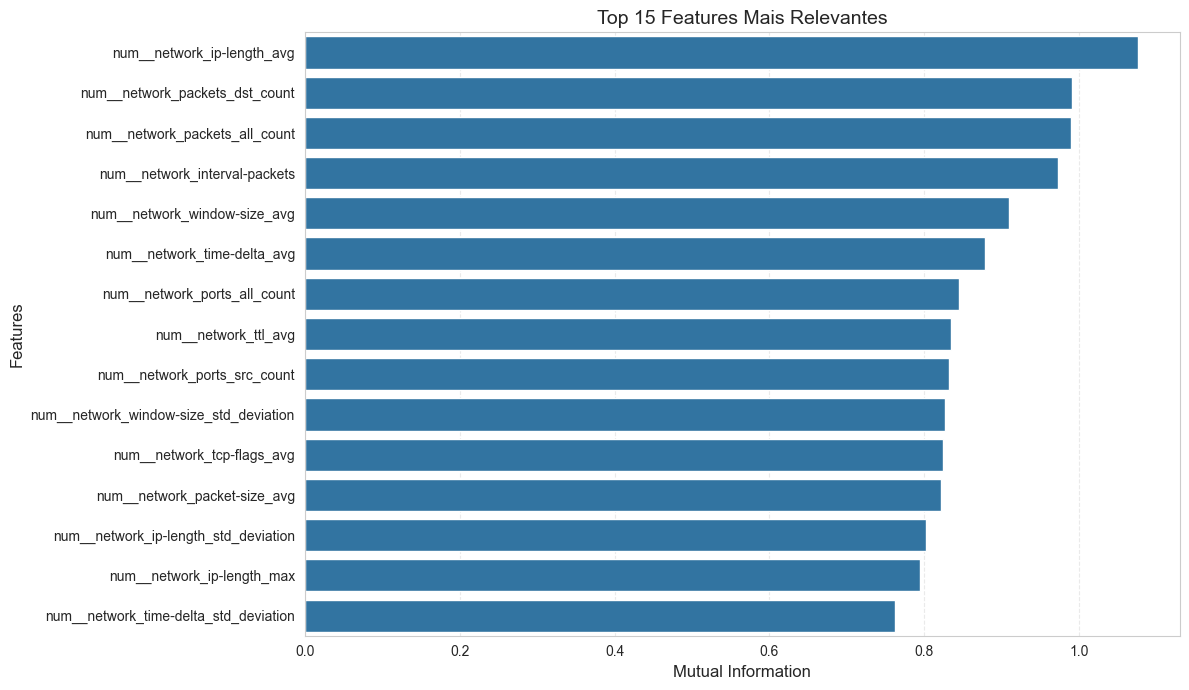

VISUALIZAÇÃO DAS FEATURES FINALIZADA


In [36]:

# TOP FEATURES
top_features = feature_importance.head(15)

# FIGURA
plt.figure(figsize=(12,7))


# BARPLOT
sns.barplot(

    data=top_features,

    x="Mutual_Information",

    y="Feature"
)


# TÍTULO
plt.title(

    "Top 15 Features Mais Relevantes",

    fontsize=14
)


# LABELS
plt.xlabel(

    "Mutual Information",

    fontsize=12
)

plt.ylabel(

    "Features",

    fontsize=12
)


# GRID
plt.grid(

    axis="x",

    linestyle="--",

    alpha=0.4
)

# AJUSTE FINAL
plt.tight_layout()


# EXIBE
plt.show()

print("==================================================")
print("VISUALIZAÇÃO DAS FEATURES FINALIZADA")
print("==================================================")

# 11. SAMPLE WEIGHT

In [ ]:
"""
Balancea automaticamente as classes.
"""

sample_weight = compute_sample_weight(

    class_weight="balanced",

    y=y_train
)

print("Sample weights calculados.")

Sample weights calculados.


# 12. DEFINIÇÃO DO MODELO BASE

In [ ]:
model_base = LogisticRegression(

    # reduzido de 5000 -> 1000
    # acelera MUITO o treinamento
    max_iter=1000,

    random_state=42,


    solver="lbfgs",

    # mantém balanceamento automático
    class_weight="balanced"
)

print("Modelo base configurado.")

Modelo base configurado.


# 13. GRID SEARCH

In [ ]:
#LOOP DE EXPERIMENTOS E GERAÇÃO DE ARQUIVOS

experimentos = [
    {"suffix": "all", "target": "label4"},
    {"suffix": "binary", "target": "label1"},
    {"suffix": "grouped", "target": "label2"}
]

print(f"Iniciando loop de treinamento para {len(experimentos)} cenários...")

for exp in experimentos:

    print(f"\n--- Processando cenário: {exp['suffix']} ---")

    y_train_exp = df_train[exp['target']]
    y_test_exp = df_test[exp['target']]

    
    # TRANSFORMER
    transformer_integrado = Pipeline(steps=[

        ('preprocessor', preprocessor),

        # ALTERADO:
        # reduzimos de 80 para 50
        # acelera MUITO o treino
        ('selector', SelectKBest(
            score_func=mutual_info_classif,
            k=50
        ))
    ])


    # MODELO
        # uso lbfgs
        # MUITO mais rápido para multinomial
    model_fast = LogisticRegression(

        max_iter=1000,

        random_state=42,

        solver="lbfgs",

        class_weight="balanced"
    )

    # ==================================================
    # PIPELINE
    # ==================================================

    full_pipeline = Pipeline(steps=[

        ('transformer', transformer_integrado),

        ('model', model_fast)
    ])

    # ==================================================
    # GRID SEARCH

    # ALTERADO:
    # removemos Grid pesado
    # apenas 1 configuração
    param_grid = {

        "model__C": [1.0]
    }

    grid = GridSearchCV(

        estimator=full_pipeline,

        param_grid=param_grid,

        scoring="f1_macro",

        # ALTERADO:
        # cv=2 reduz MUITO o tempo
        cv=2,

        n_jobs=-1,

        verbose=2
    )

    # TREINAMENTO
    print(f"Treinando modelo ({exp['target']})...")

    # removido compute_sample_weight
    # class_weight resolve
    grid.fit(X_train, y_train_exp)


    # SALVAMENTO
    path_dir = f"results/logistic_regression_full_{exp['suffix']}"

    os.makedirs(path_dir, exist_ok=True)

    print(f"Salvando artefatos em: {path_dir}")

    # PIPELINE
    with open(f"{path_dir}/pipe.pickle", 'wb') as f:

        pickle.dump(grid.best_estimator_, f)

    # PROBABILIDADES
    y_prob_train = grid.best_estimator_.predict_proba(X_train)

    y_prob_test = grid.best_estimator_.predict_proba(X_test)

    pd.DataFrame(
        y_prob_train,
        columns=grid.best_estimator_.classes_

    ).to_parquet(
        f"{path_dir}/train_predict_proba.parquet"
    )

    pd.DataFrame(
        y_prob_test,
        columns=grid.best_estimator_.classes_

    ).to_parquet(
        f"{path_dir}/test_predict_proba.parquet"
    )

    # IMPORTÂNCIA
    features_finais = (
        grid.best_estimator_
        .named_steps['transformer']
        .get_feature_names_out()
    )

    coefs = np.mean(

        np.abs(
            grid.best_estimator_
            .named_steps['model']
            .coef_
        ),

        axis=0
    )

    pd.DataFrame({

        'feature': features_finais,

        'importance': coefs

    }).sort_values(

        by='importance',

        ascending=False

    ).to_csv(

        f"{path_dir}/feature_importances.csv",

        index=False
    )

    print(f"Cenário '{exp['suffix']}' concluído com sucesso!")

print("\nTODOS OS EXPERIMENTOS FORAM FINALIZADOS!")

Iniciando loop de treinamento para 3 cenários...

--- Processando cenário: all ---
Treinando modelo (label4)...
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Salvando artefatos em: results/logistic_regression_full_all
Cenário 'all' concluído com sucesso!

--- Processando cenário: binary ---
Treinando modelo (label1)...
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Salvando artefatos em: results/logistic_regression_full_binary
Cenário 'binary' concluído com sucesso!

--- Processando cenário: grouped ---
Treinando modelo (label2)...
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Salvando artefatos em: results/logistic_regression_full_grouped
Cenário 'grouped' concluído com sucesso!

TODOS OS EXPERIMENTOS FORAM FINALIZADOS!


# 14. PREDIÇÃO MULTICLASSE

In [ ]:
"""
Executa predições e analisar a confiança do modelo final 
(baseado no último experimento do loop).
"""

#melhor modelo do ÚLTIMO experimento rodado no loop (Geralmente o 'grouped')
best_model = grid.best_estimator_
check_is_fitted(best_model)

print("Gerando probabilidades e predições...")
y_prob = best_model.predict_proba(X_test)
y_pred = best_model.predict(X_test)

# Classes e Cálculo de Confiança
classes = best_model.classes_
max_prob = np.max(y_prob, axis=1)
sorted_probs = np.sort(y_prob, axis=1)
second_best_prob = sorted_probs[:, -2]
confidence_margin = max_prob - second_best_prob

# Montagem do DataFrame de Resultados
df_result = pd.DataFrame({
    "Classe_Real": y_test_exp.values, 
    "Classe_Predita": y_pred,
    "Probabilidade_Maxima": max_prob,
    "Segunda_Probabilidade": second_best_prob,
    "Margem_Confianca": confidence_margin
})

# Verificação de acerto
df_result["Correto"] = df_result["Classe_Real"] == df_result["Classe_Predita"]

print("-" * 30)
print(f"Resumo da Predição ({exp['suffix']}):")
print(f"Total de amostras: {len(df_result)}")
print(f"Acertos:           {df_result['Correto'].sum()}")
print(f"Erros:             {(~df_result['Correto']).sum()}")
print("-" * 30)

display(df_result.head())

Gerando probabilidades e predições...
------------------------------
Resumo da Predição (grouped):
Total de amostras: 56798
Acertos:           46094
Erros:             10704
------------------------------


,Classe_Real,Classe_Predita,Probabilidade_Maxima,Segunda_Probabilidade,Margem_Confianca,Correto
0,benign,benign,0.284292,0.212830,0.071463,True
1,benign,benign,0.390426,0.162827,0.227599,True
2,benign,benign,0.390426,0.162827,0.227599,True
3,recon,recon,0.989465,0.008814,0.980651,True
4,benign,benign,0.390426,0.162827,0.227599,True


# 15. AMOSTRAS MAIS CONFIANTES

In [ ]:
"""
Identifica e exibir as amostras onde o modelo teve o 
maior grau de certeza (Top 20).
"""

# Ordenação por probabilidade máxima
mais_confiantes = df_result.sort_values(
    by="Probabilidade_Maxima",
    ascending=False
)

print(f"Análise de confiança concluída para o cenário: {exp['suffix']}")
print(f"Shape da matriz de probabilidades: {y_prob.shape} (Amostras, Classes)")

display(mais_confiantes.head(20))

Análise de confiança concluída para o cenário: grouped
Shape da matriz de probabilidades: (56798, 8) (Amostras, Classes)


,Classe_Real,Classe_Predita,Probabilidade_Maxima,Segunda_Probabilidade,Margem_Confianca,Correto
15030,recon,recon,1.0,5.125709e-10,1.0,True
1847,recon,recon,1.0,1.177873e-08,1.0,True
40386,recon,recon,1.0,1.224780e-08,1.0,True
25643,malware,malware,1.0,2.857000e-08,1.0,True
8766,recon,recon,1.0,3.284232e-08,1.0,True
41822,recon,recon,1.0,2.996462e-08,1.0,True
29033,recon,recon,1.0,3.503632e-08,1.0,True
21073,recon,recon,1.0,4.163598e-08,1.0,True
44672,recon,recon,1.0,5.087901e-08,1.0,True
34390,malware,malware,1.0,5.871990e-08,1.0,True


# 16. AMOSTRAS MAIS INCERTAS

In [42]:
"""
Identifica amostras onde o modelo teve maior dificuldade 
de decisão (menor margem entre as duas melhores classes).
"""

# Ordenação ascendente: menores margens primeiro
mais_incertas = df_result.sort_values(
    by="Margem_Confianca",
    ascending=True
)

print(f"Analisando amostras críticas do cenário: {exp['suffix']}")
print("As amostras abaixo possuem probabilidades muito próximas para classes diferentes.")

display(mais_incertas.head(20))

Analisando amostras críticas do cenário: grouped
As amostras abaixo possuem probabilidades muito próximas para classes diferentes.


,Classe_Real,Classe_Predita,Probabilidade_Maxima,Segunda_Probabilidade,Margem_Confianca,Correto
16104,benign,bruteforce,0.485359,0.485359,2.278490e-07,False
51480,benign,malware,0.243312,0.243295,1.680380e-05,False
39646,benign,benign,0.243353,0.243252,1.011264e-04,True
52183,benign,benign,0.428108,0.427946,1.619721e-04,True
17501,benign,mitm,0.420560,0.420347,2.131648e-04,False
25142,benign,benign,0.267924,0.267704,2.197363e-04,True
48288,benign,bruteforce,0.273739,0.273464,2.749345e-04,False
41065,benign,benign,0.376274,0.375957,3.175840e-04,True
44467,benign,bruteforce,0.315558,0.315214,3.436653e-04,False
54450,benign,malware,0.298936,0.298531,4.050456e-04,False


# 17. MÉTRICAS

In [ ]:
"""
============================================================
Avalia o desempenho estatístico do modelo final utilizando
métricas de acurácia, F1-Score e o relatório por classe.
============================================================
"""

# Usamos y_test_exp para garantir que os rótulos batam com o 
# experimento atual (all, binary ou grouped)
print(f"Avaliando métricas para o cenário: {exp['suffix']}\n")

print("Accuracy:")
print(accuracy_score(y_test_exp, y_pred))

print("\nF1 Macro (Média simples entre as classes):")
print(f1_score(y_test_exp, y_pred, average="macro"))

print("\nF1 Weighted (Média ponderada pelo suporte):")
print(f1_score(y_test_exp, y_pred, average="weighted"))

print("\nClassification Report:")
print(
    classification_report(
        y_test_exp, 
        y_pred, 
        zero_division=0
    )
)

Avaliando métricas para o cenário: grouped

Accuracy:
0.8115426599528153

F1 Macro (Média simples entre as classes):
0.6670363046862535

F1 Weighted (Média ponderada pelo suporte):
0.8259101976409045

Classification Report:
              precision    recall  f1-score   support

      benign       0.88      0.88      0.88     34200
  bruteforce       0.15      0.64      0.24       465
        ddos       0.91      0.72      0.81      4501
         dos       0.90      0.80      0.85      4582
     malware       0.68      0.73      0.71      1888
        mitm       0.30      0.58      0.39      2018
       recon       0.96      0.66      0.78      8445
         web       0.57      0.83      0.67       699

    accuracy                           0.81     56798
   macro avg       0.67      0.73      0.67     56798
weighted avg       0.86      0.81      0.83     56798



# 18. TOP-K ACCURACY

In [44]:
"""
Avaliar a probabilidade da classe real estar entre as K 
maiores probabilidades preditas pelo modelo.
"""
# O parâmetro 'labels' garante que a ordem das colunas em y_prob seja respeitada

print(f"Analisando Top-K Accuracy para: {exp['suffix']}")

top1 = top_k_accuracy_score(
    y_test_exp, 
    y_prob, 
    k=1, 
    labels=classes
)

top3 = top_k_accuracy_score(
    y_test_exp, 
    y_prob, 
    k=3, 
    labels=classes
)

top5 = top_k_accuracy_score(
    y_test_exp, 
    y_prob, 
    k=5, 
    labels=classes
)

print("-" * 30)
print(f"Top-1 Accuracy (Igual à acurácia global): {top1:.4f}")
print(f"Top-3 Accuracy:                         {top3:.4f}")
print(f"Top-5 Accuracy:                         {top5:.4f}")
print("-" * 30)

if top5 > 0.80:
    print("Insight: Embora o Top-1 seja desafiador, o modelo coloca a classe correta entre as 5 principais na maioria das vezes.")

Analisando Top-K Accuracy para: grouped
------------------------------
Top-1 Accuracy (Igual à acurácia global): 0.8115
Top-3 Accuracy:                         0.9413
Top-5 Accuracy:                         0.9788
------------------------------
Insight: Embora o Top-1 seja desafiador, o modelo coloca a classe correta entre as 5 principais na maioria das vezes.


# 19. ROC-AUC MULTICLASSE

In [ ]:
"""
============================================================
Calcula a área sob a curva ROC utilizando a estratégia 
One-vs-Rest (OvR) para avaliar a separabilidade das classes.
============================================================
"""

print(f"Calculando ROC-AUC para o cenário: {exp['suffix']}")

# Binarização dos rótulos reais para o cálculo multiclasse
# Uso o y_test_exp para manter a consistência com o loop
y_test_bin = label_binarize(y_test_exp, classes=classes)

try:
    roc_auc_macro = roc_auc_score(
        y_test_bin, 
        y_prob, 
        average="macro", 
        multi_class="ovr"
    )

    roc_auc_weighted = roc_auc_score(
        y_test_bin, 
        y_prob, 
        average="weighted", 
        multi_class="ovr"
    )

    print("-" * 30)
    print(f"ROC-AUC Macro:    {roc_auc_macro:.4f}")
    print(f"ROC-AUC Weighted: {roc_auc_weighted:.4f}")
    print("-" * 30)
    
except ValueError as e:
    # Caso ocorra erro por falta de amostras de alguma classe no fold de teste
    print(f"Aviso: Não foi possível calcular o ROC-AUC para algumas classes: {e}")

Calculando ROC-AUC para o cenário: grouped
------------------------------
ROC-AUC Macro:    0.9244
ROC-AUC Weighted: 0.9071
------------------------------


# 20. MATRIZ DE CONFUSÃO

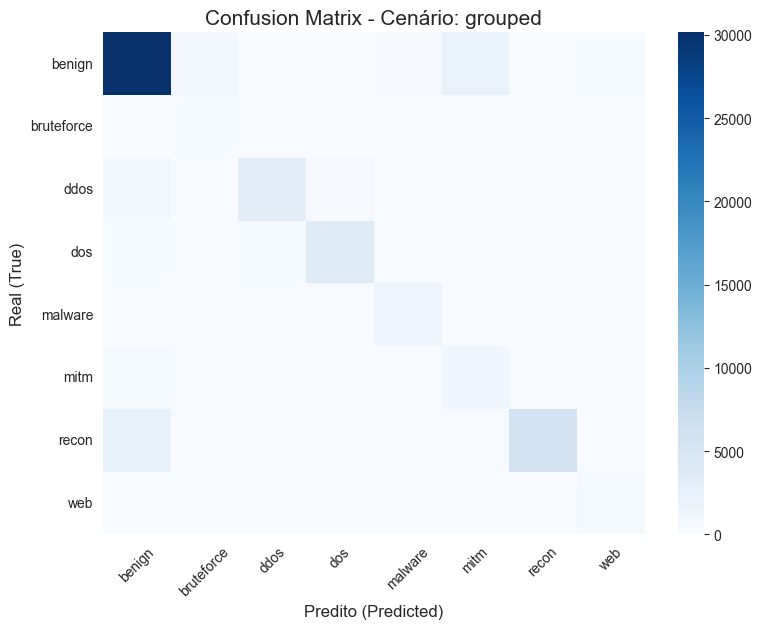

Matriz de Confusão gerada para o cenário grouped.


In [ ]:
"""
Visualizar graficamente onde o modelo está acertando e 
em quais classes ele está concentrando os erros.
"""

cm = confusion_matrix(
    y_test_exp, 
    y_pred
)

# Ajuste dinâmico do tamanho da figura baseado na quantidade de classes
size = 15 if exp['suffix'] == 'all' else 8

plt.figure(figsize=(size, size * 0.8))

# Criando o mapa de calor
sns.heatmap(
    cm, 
    cmap="Blues", 
    annot=False,  # Fica muito poluído com 84 classes, melhor deixar False
    fmt='d'
)

plt.title(f"Confusion Matrix - Cenário: {exp['suffix']}", fontsize=15)
plt.xlabel("Predito (Predicted)", fontsize=12)
plt.ylabel("Real (True)", fontsize=12)

# Se houver poucas classes (cenário binary ou grouped), podemos colocar os nomes nos eixos
if exp['suffix'] != 'all':
    plt.xticks(np.arange(len(classes)) + 0.5, classes, rotation=45)
    plt.yticks(np.arange(len(classes)) + 0.5, classes, rotation=0)

plt.tight_layout()
plt.show()

print(f"Matriz de Confusão gerada para o cenário {exp['suffix']}.")

# 21. CLASSES MAIS CONFUNDIDAS

In [ ]:
"""
Identifica os pares de classes (Real vs Predita) que geram
o maior volume de erros, facilitando o diagnóstico de sobreposição.
"""

#lista de confusões a partir da matriz 'cm' gerada na Célula #20
confusions = []

print(f"Analisando sobreposições críticas no cenário: {exp['suffix']}")

for i in range(len(classes)):
    for j in range(len(classes)):
        if i != j: # Ignoramos a diagonal principal (acertos)
            if cm[i, j] > 0: # Registramos apenas onde houve erro de fato
                confusions.append({
                    "Classe_Real": classes[i],
                    "Classe_Predita": classes[j],
                    "Quantidade": cm[i, j]
                })

# Transformação em DataFrame para facilitar a visualização
conf_df = pd.DataFrame(confusions)

# Ordenação para mostrar os erros mais frequentes no topo
conf_df = conf_df.sort_values(
    by="Quantidade", 
    ascending=False
).reset_index(drop=True)

print(f"Total de pares de classes confundidas: {len(conf_df)}")
print("-" * 30)
print("Top 20 Maiores Confusões:")
display(conf_df.head(20))

# Insight Automático
if not conf_df.empty:
    maior_erro = conf_df.iloc[0]
    print(f"\nInsight: O erro mais comum é confundir '{maior_erro['Classe_Real']}' "
          f"com '{maior_erro['Classe_Predita']}' ({maior_erro['Quantidade']} vezes).")

Analisando sobreposições críticas no cenário: grouped
Total de pares de classes confundidas: 50
------------------------------
Top 20 Maiores Confusões:


,Classe_Real,Classe_Predita,Quantidade
0,recon,benign,2398
1,benign,mitm,2191
2,benign,bruteforce,1040
3,ddos,benign,629
4,mitm,benign,547
5,benign,malware,370
6,ddos,dos,365
7,benign,web,291
8,dos,benign,290
9,dos,ddos,270



Insight: O erro mais comum é confundir 'recon' com 'benign' (2398 vezes).


# 22. PCA

Executando PCA para o cenário: grouped...


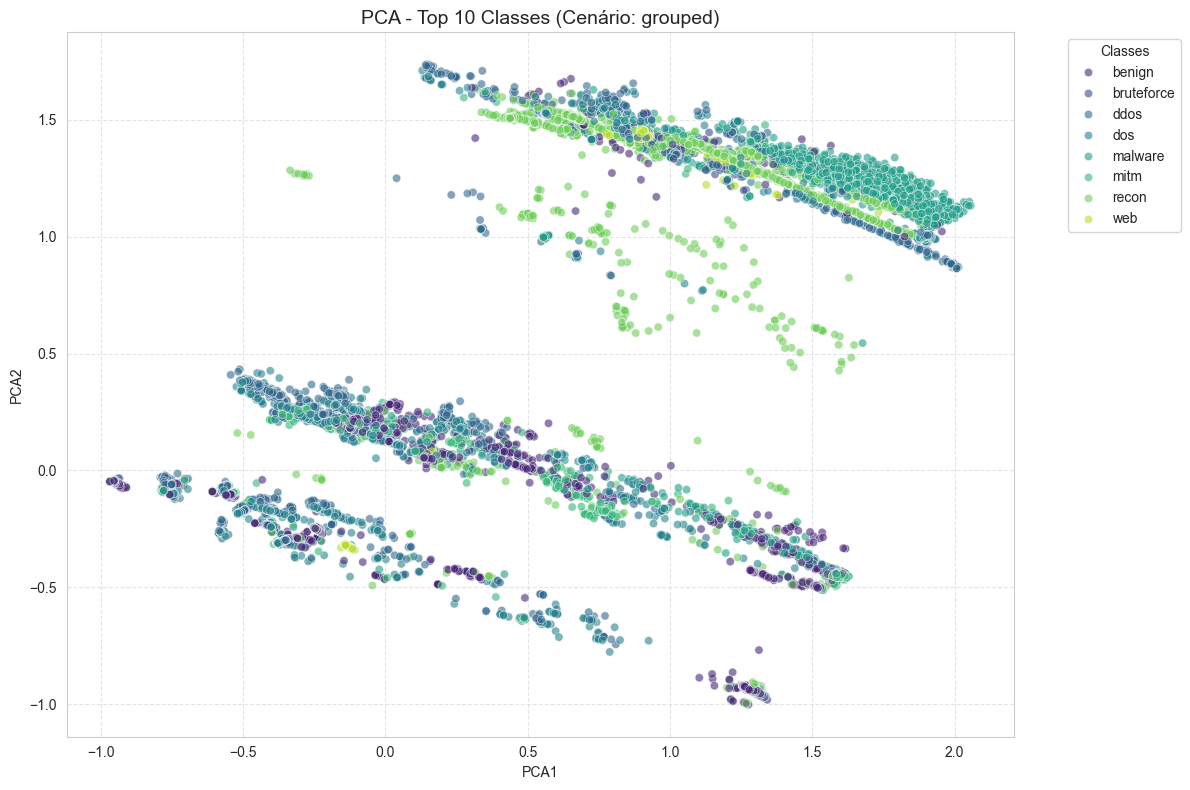

Visualização PCA concluída.


In [48]:
"""
============================================================
OBJETIVO:
Reduzir as 180 features para apenas 2 dimensões principais 
(PCA) para visualizar a separação das Top 10 classes.
============================================================
"""

print(f"Executando PCA para o cenário: {exp['suffix']}...")

# 1. Extrair os dados processados (X_test) usando o transformer da Pipeline
# Isso garante que o PCA rode sobre os dados numéricos e normalizados
X_test_transformed = best_model.named_steps['transformer'].transform(X_test)

# 2. Configurar e rodar o PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_transformed)

# 3. Criar DataFrame para plotagem
# Usamos y_test_exp para garantir que os nomes das classes estejam corretos
df_pca = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "Classe": y_test_exp.values
})

# 4. Selecionar apenas as Top 10 classes mais frequentes para evitar poluição visual
top_classes = y_test_exp.value_counts().head(10).index
df_plot = df_pca[df_pca["Classe"].isin(top_classes)]

# 5. Visualização
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_plot,
    x="PCA1",
    y="PCA2",
    hue="Classe",
    alpha=0.6,
    palette="viridis"
)

plt.title(f"PCA - Top 10 Classes (Cenário: {exp['suffix']})", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Classes")
plt.tight_layout()
plt.show()

print("Visualização PCA concluída.")

# 23. t-SNE

Iniciando t-SNE para o cenário: grouped...


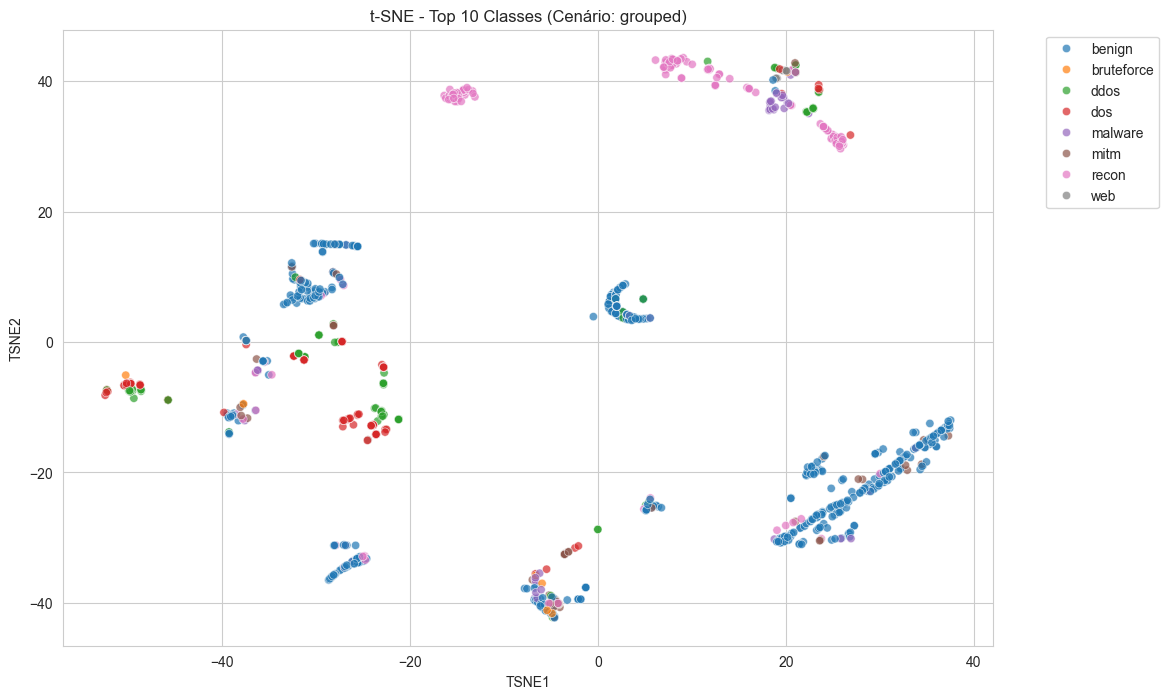

Visualização t-SNE concluída.


In [49]:
print(f"Iniciando t-SNE para o cenário: {exp['suffix']}...")

sample_size = 1500

# 1. Transformar os dados brutos usando o transformer da Pipeline
X_test_transformed = best_model.named_steps['transformer'].transform(X_test)

# 2. Extrair amostra dos dados já transformados
X_tsne_sample = X_test_transformed[:sample_size]
y_tsne_sample = y_test_exp.iloc[:sample_size]

# 3. Rodar t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_tsne_sample)

df_tsne = pd.DataFrame({
    "TSNE1": X_tsne[:,0],
    "TSNE2": X_tsne[:,1],
    "Classe": y_tsne_sample.values
})

# Plotagem das Top 10
top_classes = y_test_exp.value_counts().head(10).index
df_plot = df_tsne[df_tsne["Classe"].isin(top_classes)]

plt.figure(figsize=(12,8))
sns.scatterplot(data=df_plot, x="TSNE1", y="TSNE2", hue="Classe", alpha=0.7, palette="tab10")
plt.title(f"t-SNE - Top 10 Classes (Cenário: {exp['suffix']})")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print("Visualização t-SNE concluída.")

# 24. SHAP VALUES

Calculando SHAP para o cenário: grouped...

TOP FEATURES - IMPORTÂNCIA GLOBAL


,Feature,SHAP_Global
48,num__network_window-size_std_deviation,1.732425
45,num__network_window-size_avg,1.399974
46,num__network_window-size_max,0.850471
41,num__network_ttl_avg,0.836518
42,num__network_ttl_max,0.831308
2,num__network_ip-flags_std_deviation,0.792583
35,num__network_tcp-flags_min,0.646813
1,num__network_ip-flags_avg,0.594431
44,num__network_ttl_std_deviation,0.588578
43,num__network_ttl_min,0.553730


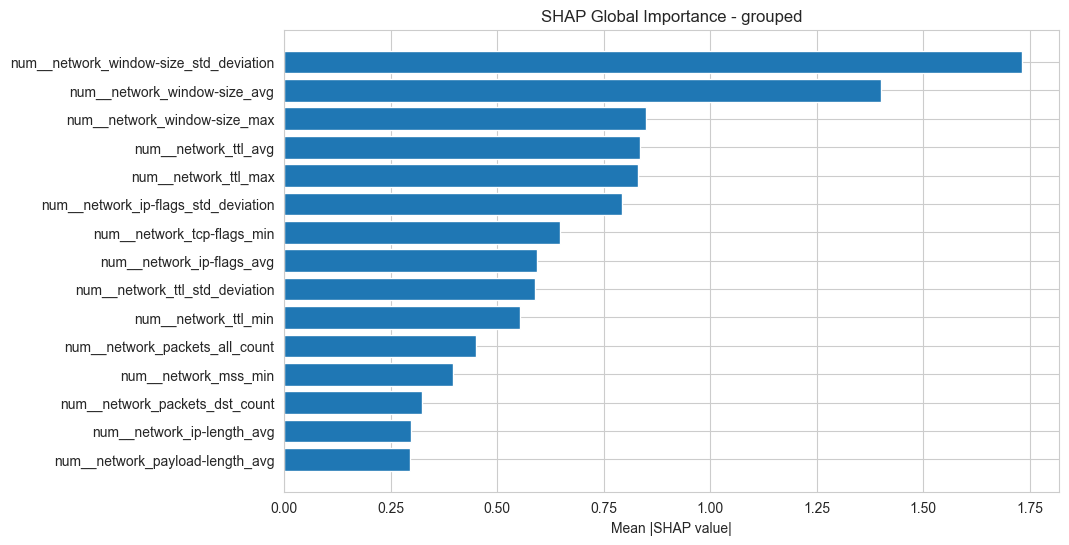


SHAP LOCAL - ANÁLISE DE ERRO


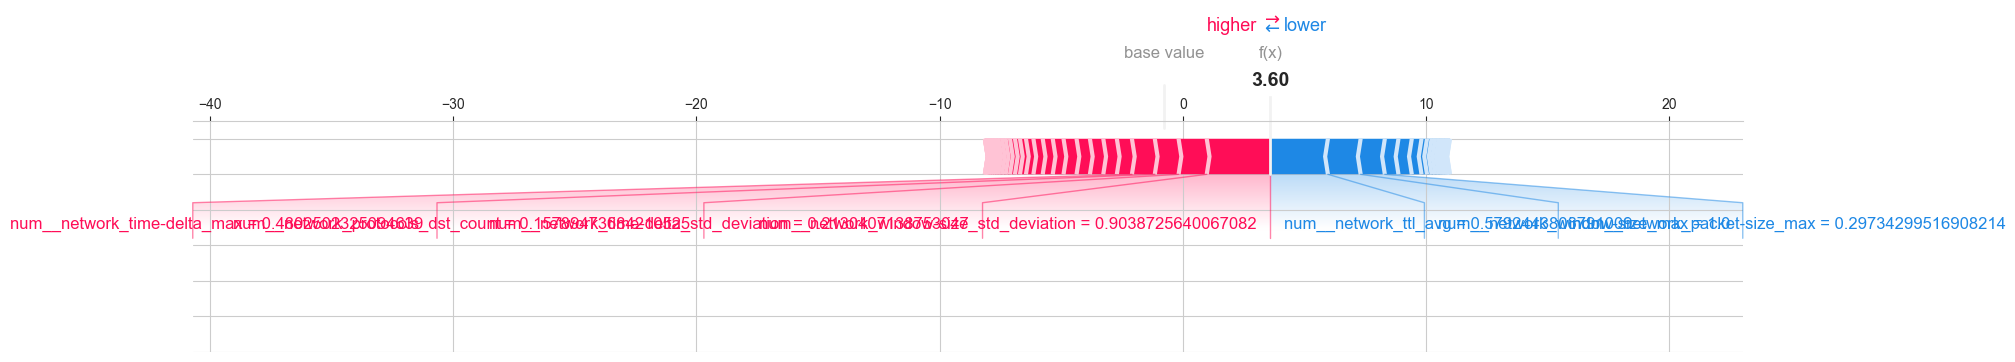


Análise SHAP para grouped concluída!


In [ ]:
"""
Interpreta o modelo treinado utilizando SHAP,
identificando:

1. Features mais importantes globalmente
2. Impacto local de uma predição errada

shap.Explainer é:
- mais moderno
- mais compatível
- mais estável
- recomendado nas versões atuais do SHAP
"""

print(f"Calculando SHAP para o cenário: {exp['suffix']}...")

# 1. AMOSTRA REDUZIDA
# acelera MUITO o processamento
sample_size = 100

# Dados transformados
X_test_transformed = (
    best_model
    .named_steps['transformer']
    .transform(X_test)
)

#apenas uma amostra
X_sample = X_test_transformed[:sample_size]


# 2. FEATURES SELECIONADAS
# Features que sobreviveram ao SelectKBest
selected_features = (
    best_model
    .named_steps['transformer']
    .get_feature_names_out()
)


# 3. EXPLAINER SHAP
# shap.Explainer()
# mais moderno e estável
explainer = shap.Explainer(

    best_model.named_steps['model'],

    X_sample
)

shap_values = explainer(X_sample)


# valores numéricos
shap_array = shap_values.values

# Classes do modelo
class_names = best_model.classes_


# 4. IMPORTÂNCIA GLOBAL
# Multiclasse:
# eixo:
# 0 -> amostras
# 1 -> features
# 2 -> classes

global_importance = np.mean(

    np.abs(shap_array),

    axis=(0, 2)
)

# DataFrame de importância
df_global = pd.DataFrame({

    "Feature": selected_features,

    "SHAP_Global": global_importance

}).sort_values(

    by="SHAP_Global",

    ascending=False
)

print("\nTOP FEATURES - IMPORTÂNCIA GLOBAL")

display(df_global.head(20))

# 5. VISUAL GLOBAL
plt.figure(figsize=(10,6))

top_features_shap = df_global.head(15)

plt.barh(

    top_features_shap["Feature"][::-1],

    top_features_shap["SHAP_Global"][::-1]

)

plt.title(

    f"SHAP Global Importance - {exp['suffix']}"
)

plt.xlabel("Mean |SHAP value|")

plt.show()

# 6. SHAP LOCAL — ANÁLISE DE ERRO
print("\n==============================")
print("SHAP LOCAL - ANÁLISE DE ERRO")
print("==============================")

try:

    # Primeiro erro do modelo
    error_idx = (
        df_result[df_result["Correto"] == False]
        .index[0]
    )

    # Verifica se o erro está dentro da amostra
    if error_idx < sample_size:

        pred_class_name = (
            df_result.loc[error_idx, "Classe_Predita"]
        )

        class_idx = list(class_names).index(
            pred_class_name
        )

        # ALTERADO:
        # pega o valor base corretamente
        base_value = shap_values.base_values[
            error_idx,
            class_idx
        ]

        # Force Plot
        shap.force_plot(

            base_value,

            # ALTERADO:
            # formato correto multiclasse
            shap_array[error_idx][:, class_idx],

            X_sample[error_idx],

            feature_names=selected_features,

            matplotlib=True
        )

    else:

        print("O primeiro erro está fora da amostra SHAP.")

        print("Aumente o sample_size se desejar.")

except Exception as e:

    print(f"Não foi possível gerar o Force Plot: {e}")

print(f"\nAnálise SHAP para {exp['suffix']} concluída!")